In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import firwin, lfilter, find_peaks

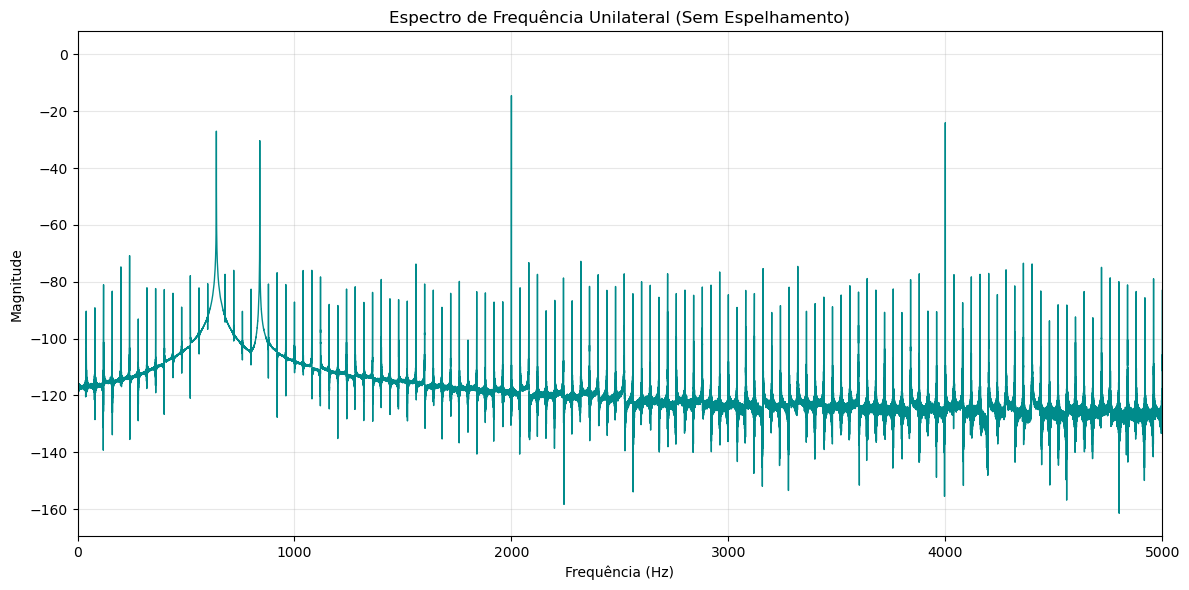

In [16]:
# 1. Carregar o arquivo
fs, data = wavfile.read('./audios/sinal_1.wav')# Normalizar o sinal se necessário

if len(data.shape) > 1:
    data = data[:, 0]

# Normalizamos a amplitude para facilitar a visualização (entre -1 e 1)
data = data / np.max(np.abs(data))

# 2. Cálculo da FFT
n = len(data)
fft_values = np.fft.fft(data)
freqs = np.fft.fftfreq(n, d=1/fs)

# 3. Pegar apenas frequências positivas
indices_positivos = np.where(freqs >= 0)
f_plot = freqs[indices_positivos]
magnitude_linear = np.abs(fft_values[indices_positivos])

# 4. Conversão para Decibéis (dB)
# Normalizamos pela magnitude máxima para que o pico principal seja 0 dB
magnitude_db = 20 * np.log10(magnitude_linear / np.max(magnitude_linear))

# 5. Visualização com ZOOM e Escala em dB
plt.figure(figsize=(12, 6))
plt.plot(f_plot, magnitude_db, color='darkcyan', linewidth=1)

plt.title('Espectro de Frequência Unilateral (Sem Espelhamento)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0,5000)  # Limita até 8000 Hz (Nyquist)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Número de componentes encontradas: 1
Componente 1: 2000.00 Hz


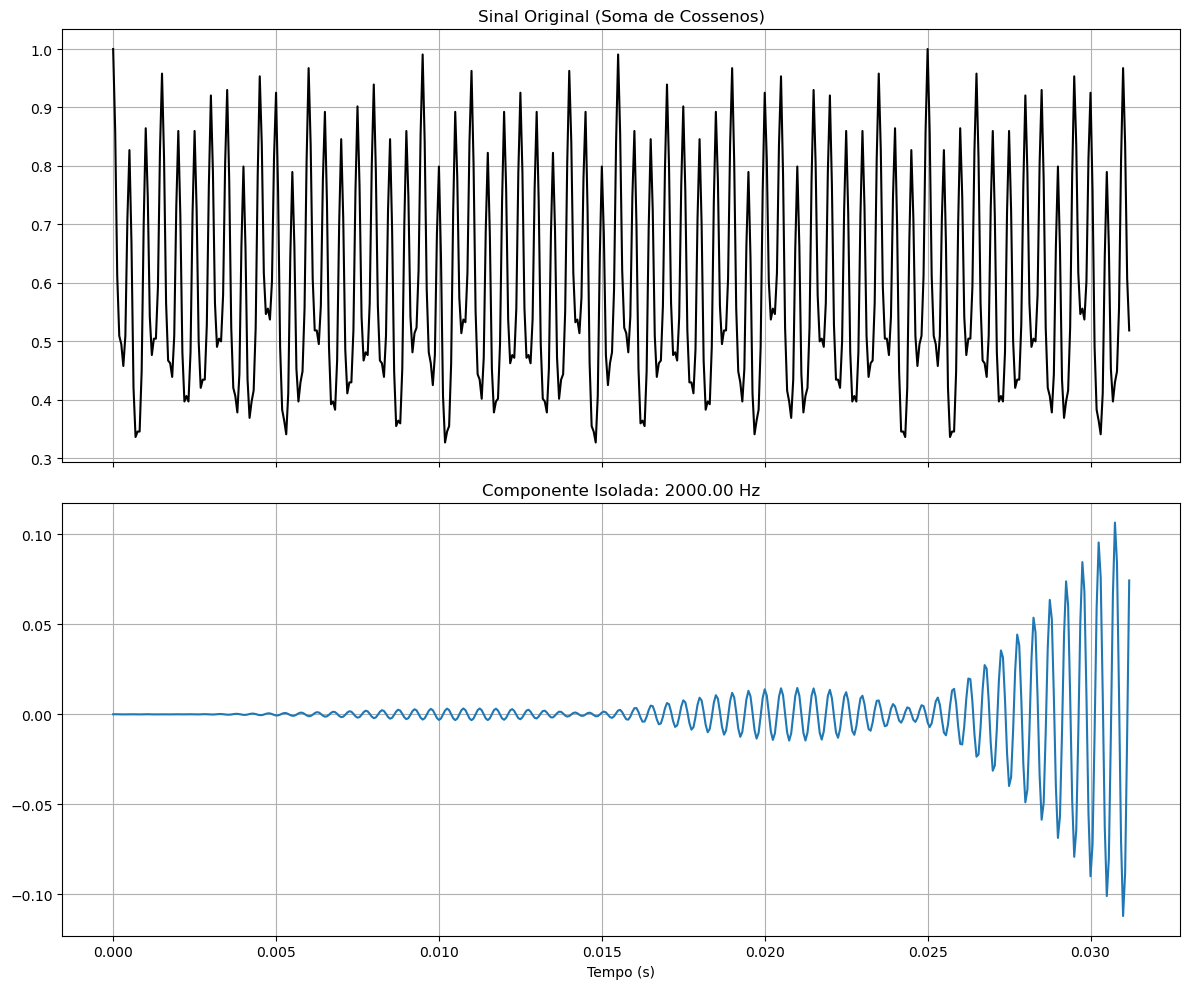

In [17]:
fs, data = wavfile.read('./audios/sinal_1.wav')# Normalizar o sinal se necessário


# Se for stereo, converte para mono
if len(data.shape) > 1:
    data = data[:, 0]

# Normalização para facilitar o processamento
data = data / np.max(np.abs(data))
n = len(data)

# 2. Identificar as componentes (FFT)
fft_values = np.fft.fft(data)
freqs = np.fft.fftfreq(n, d=1/fs)

# Pegamos apenas a parte positiva
half_n = n // 2
magnitude = np.abs(fft_values[:half_n])
f_plot = freqs[:half_n]

# Encontrar os picos (componentes) automaticamente
# 'prominence' ajuda a ignorar ruídos pequenos
indices_picos, _ = find_peaks(magnitude, prominence=np.max(magnitude)*0.1)
freqs_componentes = f_plot[indices_picos]

print(f"Número de componentes encontradas: {len(freqs_componentes)}")
for i, f in enumerate(freqs_componentes):
    print(f"Componente {i+1}: {f:.2f} Hz")

# 3. Criar o Sistema de Separação (Filtros FIR)
# Vamos criar um gráfico para o sinal original e um para cada componente
fig, axes = plt.subplots(len(freqs_componentes) + 1, 1, figsize=(12, 10), sharex=True)

# Plot do sinal original (um pequeno trecho para ver a forma de onda)
tempo = np.arange(n) / fs
axes[0].plot(tempo[:500], data[:500], color='black')
axes[0].set_title("Sinal Original (Soma de Cossenos)")
axes[0].grid(True)

# Loop para filtrar e separar cada componente
for i, f_alvo in enumerate(freqs_componentes):
    # Projeto do Filtro FIR Passa-Faixa
    # Definimos uma banda estreita ao redor da frequência encontrada (ex: +/- 50Hz)
    margem = 50 
    cutoff = [f_alvo - margem, f_alvo + margem]
    
    # numtaps: Ordem do filtro (quanto maior, mais preciso o corte)
    numtaps = 1001 
    taps = firwin(numtaps, cutoff, fs=fs, pass_zero=False)
    
    # Aplicação do Filtro
    sinal_filtrado = lfilter(taps, 1.0, data)
    
    # Plot da componente isolada
    axes[i+1].plot(tempo[:500], sinal_filtrado[:500], color='C'+str(i))
    axes[i+1].set_title(f"Componente Isolada: {f_alvo:.2f} Hz")
    axes[i+1].grid(True)

plt.xlabel("Tempo (s)")
plt.tight_layout()
plt.show()